# v3 — DINOv3 ViT-L/16 + page-aware multi-scale views (EDA round 2)

**v2: OOF corrupt 0.9735, LB 0.91514.** Penyebab gap (`eda/08–11`, `prepro/06–07`):
1. **Page** (poster/tabel/foto buku, tinggi ≥250px): train 5.3% vs **test 24.6%**. OOF v2 di page hanya 0.744.
   OOF di-reweight ke komposisi test = 0.930 → **75% gap = komposisi**.
2. v2 merender glyph page **3.5px = 0.22 patch** (line: 57px = 3.6 patch). Page glyph <8px: acc 0.684, sisanya 0.972.
3. Line test low-confidence 10× OOF: shift vertikal besar + bar hitam/abu/ber-noise tidak tersimulasi & tidak terhapus.
4. Test prior (EM): pegon ~23%, jawi ~9% (train 8% / 21%).

**Perubahan v3 (semua sudah dicek visual + angka di `prepro/06–07`)**
| | v2 | v3 |
|---|---|---|
| Page eval | 1 letterbox 160×640 | global + ≤6 tile ink-rich per skala glyph (24, 44 px), agregasi log-prob **conf-weighted** |
| Page train | letterbox | `train_page_view`: tile acak di skala glyph 18–56px (30% global), boost sampler ×3 |
| Sintetis page | — | `stack_view`: 2–4 line kelas sama ditumpuk (p=0.15) |
| Bar | hanya fill hitam solid | `remove_dark_bars` (hitam/abu/noisy, relatif) sebelum polaritas |
| Korupsi shift | 5–25%, p=.07, hitam | 5–60%, p=.12, hitam/abu/noisy/edge |
| Pilih epoch | F1 val corrupt | **F1 val test-like di-reweight ke komposisi test** (proxy LB) |
| Output | submission | + `submission_prior.csv` (koreksi prior EM) |

Probe frozen DINOv3-S (page train, group CV): acc page 0.472 → 0.603, line 0.981 → 0.978. Domain AUC line 0.706 → 0.681.

**Run di vast.ai (RTX 5090)**: sama seperti v2 — torch ≥2.7 cu128, upload `data/` (+ `data/folds.csv`, `data/test_train_twins.csv`), Run All.
`SMOKE_TEST=True` untuk cek cepat. Output `results/v3/<RUN_NAME>/`, fold selesai di-skip saat rerun.

In [1]:
import os, io, gc, json, math, random, time, platform
from pathlib import Path
from multiprocessing import Pool

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import timm
from timm.optim import param_groups_layer_decay
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from PIL import Image
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


def find_root():
    for c in [Path.cwd(), Path.cwd().parent, Path('/workspace/infest-26'), Path('/workspace')]:
        if (c / 'data/train.csv').exists():
            return c
    raise FileNotFoundError('data/train.csv tidak ditemukan - set ROOT manual')


ROOT = find_root()
DATA = ROOT / 'data'

SMOKE_TEST = False            # True: fold 0, 1 epoch
RUN_NAME = 'main'             # output + resume key: results/v3/<RUN_NAME>
SEED = 42
MODEL_NAME = 'vit_large_patch16_dinov3.lvd1689m'
H, W = 160, 640
EPOCHS, WARMUP_EPOCHS, PATIENCE = 15, 1, 5
MICRO_BATCH, ACCUM = 16, 2
EVAL_BATCH = 64
GRAD_CKPT = False
BASE_LR, HEAD_LR = 4e-5, 3e-4
LAYER_DECAY, WEIGHT_DECAY = 0.85, 0.05
LABEL_SMOOTHING = 0.1
NONLINE_BOOST = 1.5           # block/glyph (v2)
PAGE_BOOST = 3.0              # eda/08: page test/train = 4.6x
PAGE_CORRUPT_P = 0.5          # test pages mostly clean web images
STACK_P = 0.15                # stack_view instead of a line sample
PAGE_TARGETS, PAGE_TILES_K = (24, 44), 6   # prepro/07: (24,44) ~ (32,56) ~ (20,32,48), cheapest
FOLDS = [0, 1, 2, 3, 4]
NUM_WORKERS = max(4, min(28, (os.cpu_count() or 8) - 2))
RAW_MAX_SIDE = 1600
USE_TWINS = True
SAVE_WEIGHTS = False
LABELS = ['bali', 'jawa', 'jawi', 'lampung', 'lontara', 'pegon', 'sunda']
LABEL_TO_ID = {l: i for i, l in enumerate(LABELS)}
CTYPES = ['line', 'block', 'glyph', 'page']
if SMOKE_TEST:
    EPOCHS, FOLDS, RUN_NAME = 1, [0], 'smoke'

assert torch.cuda.is_available(), 'Butuh GPU CUDA'
DEVICE = torch.device('cuda')
cap = torch.cuda.get_device_capability()
assert cap[0] < 12 or any(a.startswith('sm_12') for a in torch.cuda.get_arch_list()), \
    'torch ini tidak support RTX 5090 (sm_120): pip install -U torch torchvision --index-url https://download.pytorch.org/whl/cu128'
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True


def seed_all(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)


seed_all(SEED)
OUT = ROOT / 'results' / 'v3' / RUN_NAME
OUT.mkdir(parents=True, exist_ok=True)
print(dict(root=str(ROOT), torch=torch.__version__, timm=timm.__version__, gpu=torch.cuda.get_device_name(),
           capability=cap, cpus=os.cpu_count(), workers=NUM_WORKERS, out=str(OUT)))

{'root': '/workspace', 'torch': '2.11.0+cu128', 'timm': '1.0.29', 'gpu': 'NVIDIA GeForce RTX 5090', 'capability': (12, 0), 'cpus': 96, 'workers': 28, 'out': '/workspace/results/v3/main'}


## Pipeline (disalin dari `prepro/pipeline.py` round 2)
Train: raw → `corrupt` → `preprocess` → canvas / `train_page_view` / `stack_view`. Eval: `preprocess` → tiles (line) atau `page_views` (page).

In [2]:
"""Preprocessing + augmentation for INFEST aksara classification. Import this from the training notebook.

Order matters:   raw RGB --(train only) corrupt()--> preprocess() --> to_canvas()
corrupt() BEFORE preprocess() because the test corruptions were applied to raw images; the network must
see train images that went through exactly the same normalisation the corrupted test images go through.

Every number below comes from eda/outputs (see eda/README.md):
  rotation +-15 deg          07: test |skew| p95=10, p99=13; 30% of test lines >=3 deg (train 4%)
  tint p=.45                 03: bg_sat>12 in 44% test vs 3% train
  blur/pixelate p=.55        03: sharp<0.6 in 69% test vs 12% train
  occluder p=.12, dashes .15 03 flat_gray 6.6% test (detector under-counts, seen in 02 zoom)
  black bar p=.07            03: black border 7.3% test vs 1.2% train
  jpeg p=.3                  01: JPEG 21% test vs 4.6% train
  canvas H=160 fixed height  07: letterbox 160x640 leaves bali/lontara at ~2 patches of ink
"""
import io
import math
import random

import numpy as np
from PIL import Image, ImageDraw, ImageFilter, ImageOps
from scipy import ndimage as ndi


# ----------------------------------------------------------------------------- load
def load_rgb(path):
    with Image.open(path) as im:
        im = ImageOps.exif_transpose(im)
        if im.mode in ("RGBA", "LA", "P", "PA"):
            im = im.convert("RGBA")
            im = Image.alpha_composite(Image.new("RGBA", im.size, "white"), im)
        return im.convert("RGB")


# ----------------------------------------------------------------------------- deterministic (train + test)
def _otsu(g):
    hist = np.bincount(g.ravel(), minlength=256).astype(float)
    p = hist / hist.sum(); w = np.cumsum(p); mu = np.cumsum(p * np.arange(256))
    return int(np.argmax((mu[-1] * w - mu) ** 2 / (w * (1 - w) + 1e-12)))


def remove_black_fill(g, dark=40, min_contact=0.3, min_solidity=0.9, max_holes=0.03):
    """Solid black regions glued to the border (shift / rotate fill, black bars) -> white.
    A border-touching pure-black component is fill when it has no holes (a real dark background has
    light text inside it) AND either (a) runs along >=min_contact of a side or (b) is near-convex
    (rotation corner triangle). Glyph-sized images (both sides <64px) only lose full-side bars.
    Only the thick core (survives 2px erosion) is removed, so thin strokes glued to the fill stay."""
    blk = g < dark
    if not blk.any():
        return g
    lab, n = ndi.label(blk)
    h, w = g.shape
    border = np.zeros_like(blk); border[0] = border[-1] = border[:, 0] = border[:, -1] = True
    tiny = max(h, w) < 64  # glyph-sized crops (e.g. a 20x20 bold numeral): only full-side bars count
    contact = 0.9 if tiny else min_contact
    objs = ndi.find_objects(lab)
    kill = set()
    for i in set(np.unique(lab[border & blk]).tolist()) - {0}:
        sl = objs[i - 1]
        comp = lab[sl] == i
        area = comp.sum()
        filled = ndi.binary_fill_holes(comp).sum()
        if (filled - area) / filled > max_holes or np.median(g[sl][comp]) > 15:
            continue
        run = max((lab[0] == i).sum() / w, (lab[-1] == i).sum() / w, (lab[:, 0] == i).sum() / h, (lab[:, -1] == i).sum() / h)
        if run >= contact:
            kill.add(i); continue
        if tiny or area < 0.005 * g.size:
            continue
        ys, xs = np.nonzero(comp)
        try:
            from scipy.spatial import ConvexHull
            hull = ConvexHull(np.c_[np.r_[ys, ys + 1, ys, ys + 1], np.r_[xs, xs, xs + 1, xs + 1]]).volume
        except Exception:
            continue
        if area / hull >= min_solidity:
            kill.add(i)
    if not kill:
        return g
    mask = np.isin(lab, list(kill))
    mask &= ndi.binary_dilation(ndi.binary_erosion(mask, iterations=2, border_value=1), iterations=3)
    out = g.copy()
    out[mask] = 255
    return out


def remove_dark_bars(g, dark=90, frac=0.85, max_share=0.85):
    """Full-width/height dark bands glued to a border (large vertical shift in test: black, dark-gray or
    black+salt-noise bars, eda/09) -> white. Detected on a 3x3 median so salt noise can't hide the bar.
    Skipped when the rest of the image is dark too (real dark background, handled by polarity)."""
    h, w = g.shape
    if h < 8 or w < 8:
        return g
    d = ndi.median_filter(g, 3) < dark
    def run(share):  # dark run from the border, then +2 boundary rows the 3x3 median half-lightened
        n = int(np.argmin(np.r_[share >= frac, False]))
        while n and n < len(share) and share[n] >= 0.5 and n < int(np.argmin(np.r_[share >= frac, False])) + 2:
            n += 1
        return n
    rs, cs = d.mean(1), d.mean(0)
    top, bot, left, right = run(rs), run(rs[::-1]), run(cs), run(cs[::-1])
    if not (top or bot or left or right) or top + bot >= max_share * h or left + right >= max_share * w:
        return g
    rest = g[top:h - bot, left:w - right]
    bands = np.concatenate([g[:top].ravel(), g[h - bot:].ravel(), g[:, :left].ravel(), g[:, w - right:].ravel()])
    # relative, not absolute: a dark-gray bar on a gray-tinted page must still go (06 b: absolute 128 turned
    # the whole canvas into a black block); a real dark background has rest ~ as dark as the "bar"
    if rest.size == 0 or np.median(rest) < np.median(ndi.median_filter(g, 3)[d]) + 40:
        return g
    out = g.copy()
    out[:top] = 255; out[h - bot:] = 255; out[:, :left] = 255; out[:, w - right:] = 255
    return out


def preprocess(rgb):
    """RGB PIL -> L PIL: gray, black fill removed, dark-ink-on-white, contrast normalised, cropped to ink.
    Fill removal runs BEFORE the polarity test: black rotation corners on a thin line can cover >50% of
    the frame and would otherwise flip the whole image to white-on-black (seen in debug_black_rotation.png)."""
    g = remove_black_fill(remove_dark_bars(np.asarray(rgb.convert("L"))))
    t = _otsu(g)
    if (g > t).mean() < 0.5:  # background is the majority class; if it is the dark side, invert
        g = 255 - g
    t = _otsu(g)
    ink, bg = g[g <= t], g[g > t]
    if ink.size and bg.size:
        lo, hi = np.percentile(ink, 10), np.median(bg)
        if hi - lo >= 20:  # skip blank / single-tone images
            g = np.clip((g.astype(np.float32) - lo) * 255.0 / (hi - lo), 0, 255).astype(np.uint8)
    return Image.fromarray(crop_to_ink(g))


def crop_to_ink(g, thr=128, trim=0.005, margin=0.08):
    ink = g < thr
    if ink.sum() < 20:
        return g
    def span(profile):
        c = np.cumsum(profile) / profile.sum()
        return int(np.searchsorted(c, trim)), int(np.searchsorted(c, 1 - trim))
    y0, y1 = span(ink.sum(1)); x0, x1 = span(ink.sum(0))
    if ink[y0:y1 + 1, x0:x1 + 1].mean() > 0.6:  # crop would be one solid blob (a black dash on a sparse page) -> keep all
        return g
    m = int(round(margin * max(y1 - y0, 8)))
    return g[max(0, y0 - m):y1 + m + 1, max(0, x0 - m):x1 + m + 1]


def to_canvas(img, H=160, W=640, train=False, rng=random):
    """Line-like crops (w/h>=2): resize to fixed height H, then random window (train) or tiles (eval).
    Others (posters, pages, square patches): letterbox. Returns list of HxW L images (len 1 when train)."""
    w, h = img.size
    if w / h >= 2:
        nw = max(1, round(w * H / h))
        img = img.resize((nw, H), Image.Resampling.BICUBIC if nw > w else Image.Resampling.LANCZOS)
        if nw <= W:
            c = Image.new("L", (W, H), 255); c.paste(img, ((W - nw) // 2, 0)); return [c]
        if train:
            x = rng.randint(0, nw - W); return [img.crop((x, 0, x + W, H))]
        n = math.ceil((nw - W) / (W // 2)) + 1
        xs = np.linspace(0, nw - W, n).round().astype(int)
        return [img.crop((x, 0, x + W, H)) for x in xs]
    s = min(H / h, W / w)
    img = img.resize((max(1, round(w * s)), max(1, round(h * s))), Image.Resampling.BICUBIC if s > 1 else Image.Resampling.LANCZOS)
    c = Image.new("L", (W, H), 255); c.paste(img, ((W - img.width) // 2, (H - img.height) // 2)); return [c]


# ----------------------------------------------------------------------------- train-only test-like corruption
PARCHMENT = [(236, 224, 196), (222, 205, 170), (245, 238, 214), (210, 196, 160), (196, 186, 160), (250, 246, 230), (170, 170, 170), (230, 230, 230)]
INKS = [(20, 20, 20), (90, 20, 30), (30, 70, 40), (40, 40, 90), (70, 50, 30), (60, 30, 80)]


def rotate(img, angle, fill="edge"):
    """RandomRotation that mimics the test set: frame size kept, corners filled by edge-replicate / white / black."""
    if fill == "edge":
        a = np.asarray(img); pad = max(a.shape[:2]) // 2
        big = Image.fromarray(np.pad(a, ((pad, pad), (pad, pad), (0, 0)), mode="edge"))
        big = big.rotate(angle, resample=Image.Resampling.BICUBIC)
        return big.crop((pad, pad, pad + img.width, pad + img.height))
    color = (255, 255, 255) if fill == "white" else (0, 0, 0)
    return img.rotate(angle, resample=Image.Resampling.BICUBIC, fillcolor=color)


def _ink_mask(img):
    g = np.asarray(img.convert("L")); return g < min(_otsu(g), 128)


def ink_retained(img, angle):
    """Share of the ORIGINAL ink still inside the frame after rotation (fill can't fake it)."""
    m = Image.fromarray(_ink_mask(img).astype(np.uint8) * 255)
    return (np.asarray(m.rotate(angle, resample=Image.Resampling.NEAREST, fillcolor=0)) > 0).sum() / max((np.asarray(m) > 0).sum(), 1)


def corrupt(img, rng=random):
    """RGB PIL -> RGB PIL with test-like corruptions. Rotation angle is re-drawn while <60% of the ink stays in frame."""
    w, h = img.size
    if rng.random() < 0.5:
        for _ in range(4):
            angle = rng.uniform(-15, 15)
            if ink_retained(img, angle) >= 0.6:
                img = rotate(img, angle, rng.choice(["edge"] * 5 + ["white"] * 2 + ["black"])); break
    if rng.random() < 0.25 and w > 60:  # partial crop along the line
        cw, ch = int(w * rng.uniform(0.6, 1.0)), int(h * rng.uniform(0.85, 1.0))
        x, y = rng.randint(0, w - cw), rng.randint(0, h - ch)
        img = img.crop((x, y, x + cw, y + ch)); w, h = img.size
    if rng.random() < 0.45:  # tint: re-colour ink and paper
        g = np.asarray(img.convert("L"), dtype=np.float32)[..., None] / 255
        bg = np.array(rng.choice(PARCHMENT), dtype=np.float32) * rng.uniform(0.85, 1.05)
        ink = np.array(rng.choice(INKS), dtype=np.float32) + rng.uniform(0, 60)
        img = Image.fromarray(np.clip(ink * (1 - g) + bg * g, 0, 255).astype(np.uint8))
    if rng.random() < 0.45:
        if rng.random() < 0.5:
            img = img.filter(ImageFilter.GaussianBlur(rng.uniform(0.3, 1.2) * max(h, 32) / 64))
        else:
            f = rng.uniform(0.35, 0.8)
            small = img.resize((max(4, int(w * f)), max(4, int(h * f))), Image.Resampling.BILINEAR)
            img = small.resize((w, h), rng.choice([Image.Resampling.NEAREST, Image.Resampling.BILINEAR, Image.Resampling.BICUBIC]))
    if rng.random() < 0.08:  # semi-transparent gray polygons
        over = Image.new("RGBA", img.size, (0, 0, 0, 0)); d = ImageDraw.Draw(over)
        for _ in range(rng.randint(1, 3)):
            v = rng.randint(60, 150)
            d.polygon([(rng.uniform(-.1, 1.1) * w, rng.uniform(-.1, 1.1) * h) for _ in range(3)], fill=(v, v, v, rng.randint(120, 230)))
        img = Image.alpha_composite(img.convert("RGBA"), over).convert("RGB")
    if rng.random() < 0.15:  # small black dashes / cutout
        d = ImageDraw.Draw(img)
        for _ in range(rng.randint(1, 4)):
            rw, rh = rng.uniform(.03, .1) * w, rng.uniform(.03, .1) * h + 1
            x, y = rng.uniform(0, w - rw), rng.uniform(0, h - rh)
            d.rectangle([x, y, x + rw, y + rh], fill=(0, 0, 0))
    if rng.random() < 0.12:  # vertical shift pushing text out of frame; test bars 5-70% of height (eda/09)
        a = np.asarray(img); k = min(h - 1, max(1, int(h * rng.uniform(0.05, 0.6))))
        out = np.empty_like(a)
        if rng.random() < 0.5:
            out[:h - k] = a[k:]; band, edge = slice(h - k, h), out[h - k - 1]
        else:
            out[k:] = a[:h - k]; band, edge = slice(0, k), out[k]
        fill = rng.choice(["black", "black", "gray", "noisy", "edge"])
        if fill == "edge":
            out[band] = edge
        else:
            out[band] = 0 if fill != "gray" else rng.randint(25, 70)
            if fill == "noisy":
                nz = np.random.default_rng(rng.randint(0, 2**31)).random(out[band].shape[:2]) < rng.uniform(0.1, 0.35)
                out[band][nz] = 255
        img = Image.fromarray(out)
    if rng.random() < 0.15:
        a = np.asarray(img, dtype=np.float32) + np.random.default_rng(rng.randint(0, 2**31)).normal(0, rng.uniform(5, 25), (h, w, 1))
        img = Image.fromarray(np.clip(a, 0, 255).astype(np.uint8))
    if rng.random() < 0.3:
        buf = io.BytesIO(); img.save(buf, "JPEG", quality=rng.randint(20, 75)); buf.seek(0)
        img = Image.open(buf).convert("RGB")
    return img


# ----------------------------------------------------------------------------- page images (eda/08, eda/10)
PAGE_MIN_H = 250  # raw height; 25% of test, glyphs rendered at 0.22 patches by the v2 letterbox


def glyph_height(g):
    """Median height of letter-sized connected components (upper 60% of sizes, dots excluded)."""
    ink = g < 128
    lab, n = ndi.label(ink)
    if n < 3:
        return float("nan")
    sl = ndi.find_objects(lab)
    hs = np.array([s[0].stop - s[0].start for s in sl]); ws = np.array([s[1].stop - s[1].start for s in sl])
    area = np.bincount(lab.ravel())[1:]
    ok = (hs >= 3) & (area >= 8) & (ws < 8 * hs + 10) & (hs <= max(0.25 * g.shape[0], 8))
    if ok.sum() < 3:
        return float("nan")
    hs = hs[ok]
    return float(np.median(hs[hs >= np.percentile(hs, 40)]))


def _zoom(img, z):
    z = float(np.clip(z, 0.15, 4.0))
    return img.resize((max(1, round(img.width * z)), max(1, round(img.height * z))),
                      Image.Resampling.BICUBIC if z > 1 else Image.Resampling.LANCZOS)


def _paste_tile(g, y, x, H, W):
    t = np.full((H, W), 255, np.uint8)
    c = g[y:y + H, x:x + W]; t[:c.shape[0], :c.shape[1]] = c
    return t


def page_views(pp, H=160, W=640, targets=(24, 44), k=6, ink_lo=0.03, ink_hi=0.45):
    """Eval views for a page: the global letterbox + up to k ink-rich 160x640 tiles per glyph scale.
    Two scales hedge a wrong glyph-height estimate (carved / textured pages)."""
    views = to_canvas(pp, H, W)
    gh = glyph_height(np.asarray(pp))
    if not np.isfinite(gh):
        return views
    for tgt in targets:
        g = np.asarray(_zoom(pp, tgt / gh)); h, w = g.shape
        if h <= H and w <= W:
            continue
        cands = []
        for y in range(0, max(1, h - H // 2), H // 2):
            for x in range(0, max(1, w - W // 2), W // 2):
                t = _paste_tile(g, y, x, H, W); f = (t < 128).mean()
                if ink_lo <= f <= ink_hi:
                    cands.append((abs(f - 0.15), y, x, t))
        cands.sort(key=lambda c: c[0])
        views += [Image.fromarray(c[3]) for c in cands[:k]]
    return views


def train_page_view(pp, rng=random, H=160, W=640, ink_lo=0.03, ink_hi=0.45):
    """Random page view: 30% global letterbox, else a random ink-rich tile at a random glyph scale 18-56px."""
    gh = glyph_height(np.asarray(pp))
    if rng.random() < 0.3 or not np.isfinite(gh):
        return to_canvas(pp, H, W, train=True, rng=rng)[0]
    g = np.asarray(_zoom(pp, rng.uniform(18, 56) / gh)); h, w = g.shape
    for _ in range(8):
        t = _paste_tile(g, rng.randint(0, max(0, h - H)), rng.randint(0, max(0, w - W)), H, W)
        if ink_lo <= (t < 128).mean() <= ink_hi:
            return Image.fromarray(t)
    return to_canvas(pp, H, W, train=True, rng=rng)[0]


def stack_view(pps, rng=random, H=160, W=640):
    """Synthetic page tile from 2-4 preprocessed LINE crops of one class: small line height (glyph ~15-40px),
    stacked like rows of a page. Gives the 199 train pages ~3k same-scale companions."""
    canvas = np.full((H, W), 255, np.uint8)
    lh = rng.randint(40, 80); y = rng.randint(0, 12)
    for pp in pps:
        if y + lh > H:
            break
        g = np.asarray(pp.resize((max(1, round(pp.width * lh / pp.height)), lh), Image.Resampling.LANCZOS))
        x0 = rng.randint(0, max(0, g.shape[1] - W))
        seg = g[:, x0:x0 + W]
        xo = rng.randint(0, W - seg.shape[1])
        canvas[y:y + lh, xo:xo + seg.shape[1]] = np.minimum(canvas[y:y + lh, xo:xo + seg.shape[1]], seg)
        y += lh + rng.randint(0, 10)
    return Image.fromarray(canvas)


def train_view(path, rng=random, H=160, W=640):
    return to_canvas(preprocess(corrupt(load_rgb(path), rng)), H, W, train=True, rng=rng)[0]


def eval_views(path, H=160, W=640):
    return to_canvas(preprocess(load_rgb(path)), H, W, train=False)

# ---- self-check (same asserts as prepro/pipeline.py)
img = Image.new("RGB", (400, 60), "white"); ImageDraw.Draw(img).text((10, 20), "abc def ghi jkl", fill="black")
p = preprocess(img)
assert p.mode == "L" and p.width < 400 and np.asarray(p).min() == 0
inv = preprocess(ImageOps.invert(img))  # white-on-black must come out black-on-white
assert np.asarray(inv).mean() > 128
barred = np.asarray(img).copy(); barred[-15:] = 0
g = remove_black_fill(np.asarray(Image.fromarray(barred).convert("L")))
assert (g[-15:] == 255).all() and (g < 128).sum() > 0, "bar removed, text kept"
page = np.full((800, 600), 255, np.uint8); page[::40, ::40] = 180; page[400:410, 300:360] = 0
assert crop_to_ink(page).shape == page.shape, "sparse page + black dash must not collapse to the dash"
views = to_canvas(Image.new("L", (3000, 80), 255), train=False)
assert all(v.size == (640, 160) for v in views) and len(views) > 1
bar = np.full((60, 400), 255, np.uint8); bar[20:30, 50:350] = 0; bar[-25:] = 0
bar[-25:][np.random.default_rng(0).random((25, 400)) < .25] = 255  # noisy bar
nb = remove_dark_bars(bar)
assert (nb[-25:] == 255).all() and (nb[20:30, 50:350] == 0).all(), "noisy bar removed, text kept"
dark = 255 - np.asarray(img.convert("L")); assert (remove_dark_bars(dark) == dark).all(), "dark background untouched"
tinted = np.full((60, 400), 140, np.uint8); tinted[25:35, 50:350] = 20; tinted[:18] = 45  # gray bar on gray page
assert (remove_dark_bars(tinted)[:18] == 255).all() and (remove_dark_bars(tinted)[25:35, 50:350] == 20).all()
pg = Image.new("L", (900, 700), 255); dpg = ImageDraw.Draw(pg)
for yy in range(20, 680, 30):
    dpg.text((20, yy), "lorem ipsum dolor sit amet consectetur adipiscing elit sed do", fill=0)
assert 5 <= glyph_height(np.asarray(pg)) <= 15
pv = page_views(pg); assert len(pv) > 1 and all(v.size == (640, 160) for v in pv)
assert train_page_view(pg, random.Random(1)).size == (640, 160)
assert stack_view([p, p, p], random.Random(2)).size == (640, 160)
r = random.Random(0)
for _ in range(50):
    c = corrupt(img, r); assert c.mode == "RGB"
print("pipeline self-check OK")

pipeline self-check OK


## Data, folds, content type, cache

In [3]:
train = pd.read_csv(DATA / 'train.csv')
test = pd.read_csv(DATA / 'test.csv')
sample_sub = pd.read_csv(DATA / 'sample_submission.csv')
assert set(train.label) == set(LABELS) and train.image_id.is_unique and test.image_id.is_unique
assert not set(train.image_id) & set(test.image_id)

folds_path = next((p for p in [DATA / 'folds.csv', ROOT / 'prepro/outputs/folds.csv'] if p.exists()), None)
assert folds_path is not None, 'folds.csv tidak ada: upload data/folds.csv (hasil prepro/05_make_folds.py)'
folds = pd.read_csv(folds_path)
assert set(folds.image_id) == set(train.image_id), 'folds.csv tidak cocok dengan train.csv'
train = train.merge(folds[['image_id', 'dup_group', 'fold', 'weight']], on='image_id', how='left')
assert (train.groupby('dup_group').fold.nunique() == 1).all(), 'dup_group bocor antar fold'

twins_path = next((p for p in [DATA / 'test_train_twins.csv', ROOT / 'prepro/outputs/test_train_twins.csv'] if p.exists()), None)
twins = pd.read_csv(twins_path) if twins_path else pd.DataFrame(columns=['image_id', 'train_label', 'n_labels'])
twins = twins[twins.image_id.isin(test.image_id) & (twins.n_labels == 1)]

train['path'] = [str(DATA / 'images/train' / i) for i in train.image_id]
test['path'] = [str(DATA / 'images/test' / i) for i in test.image_id]
y_all = train.label.map(LABEL_TO_ID).values


def content_type(w, h):  # eda/08, from RAW size
    if h >= PAGE_MIN_H:
        return 'page'
    if w / h >= 2:
        return 'line'
    return 'block' if w >= 80 else 'glyph'


def load_cached(path):
    img = load_rgb(path)
    w, h = img.size
    if max(img.size) > RAW_MAX_SIDE:
        img.thumbnail((RAW_MAX_SIDE, RAW_MAX_SIDE), Image.Resampling.LANCZOS)
    return np.asarray(img), np.asarray(preprocess(img)), content_type(w, h)


def testlike_val_pp(args):
    # fixed-seed test-like val: lines/blocks/glyphs corrupted, pages clean (test pages are clean web images)
    arr, j, ctype = args
    img = Image.fromarray(arr)
    if ctype != 'page':
        img = corrupt(img, random.Random(f'val-{SEED}-{j}'))
    return np.asarray(preprocess(img))


t0 = time.time()
with Pool(NUM_WORKERS) as pool:
    tr_cache = pool.map(load_cached, list(train.path), chunksize=8)
    te_cache = pool.map(load_cached, list(test.path), chunksize=8)
    train_raw = [a for a, _, _ in tr_cache]; train_pp = [p for _, p, _ in tr_cache]
    train['ctype'] = [c for _, _, c in tr_cache]
    test_pp = [p for _, p, _ in te_cache]; test['ctype'] = [c for _, _, c in te_cache]
    del tr_cache, te_cache
    train_pp_tl = pool.map(testlike_val_pp, [(a, j, c) for j, (a, c) in enumerate(zip(train_raw, train.ctype))], chunksize=8)
print(f'cache {time.time() - t0:.0f}s')

is_page = (train.ctype == 'page').values
nonline = np.array([p.shape[1] / p.shape[0] < 2 for p in train_pp])
share = pd.DataFrame({'train_%': train.ctype.value_counts(normalize=True) * 100, 'test_%': test.ctype.value_counts(normalize=True) * 100}).reindex(CTYPES).round(1)
share['test/train'] = (share['test_%'] / share['train_%']).round(2)
display(share)
CTYPE_W = (share['test_%'] / share['train_%']).to_dict()   # reweight OOF to the test mix = LB proxy
val_w_all = train.ctype.map(CTYPE_W).values
print(pd.crosstab(train.label, train.fold))
print('twins:', len(twins))

cache 14s


,train_%,test_%,test/train
ctype,,,
line,75.1,58.3,0.78
block,10.8,13.4,1.24
glyph,8.8,3.8,0.43
page,5.3,24.6,4.64


fold       0    1    2    3    4
label                           
bali      79   80   79   79   79
jawa     140  141  141  141  140
jawi     156  157  156  156  156
lampung  101  101  101  101  101
lontara   81   80   81   81   81
pegon     62   61   62   62   62
sunda    135  134  135  134  135
twins: 17


In [4]:
def views_for(pp, ctype):
    img = Image.fromarray(pp)
    if ctype == 'page':
        return page_views(img, H, W, targets=PAGE_TARGETS, k=PAGE_TILES_K)
    return to_canvas(img, H, W, train=False)


def _views_job(args):
    return [np.asarray(v, dtype=np.uint8) for v in views_for(*args)]


def build_tiles(pps, ctypes):
    with Pool(NUM_WORKERS) as pool:
        vs = pool.map(_views_job, list(zip(pps, ctypes)), chunksize=8)
    tiles = np.stack([t for v in vs for t in v])
    owner = np.concatenate([[k] * len(v) for k, v in enumerate(vs)])
    return tiles, owner


clean_tiles, clean_owner = build_tiles(train_pp, list(train.ctype))
tl_tiles, tl_owner = build_tiles(train_pp_tl, list(train.ctype))
test_tiles, test_owner = build_tiles(test_pp, list(test.ctype))
del train_pp_tl
print('tiles train/test-like/test:', len(clean_tiles), len(tl_tiles), len(test_tiles),
      '| views per test page (median):', int(np.median(np.bincount(test_owner)[(test.ctype == 'page').values])))

tiles train/test-like/test: 16866 16413 6689 | views per test page (median): 13


## Dataset + visual check

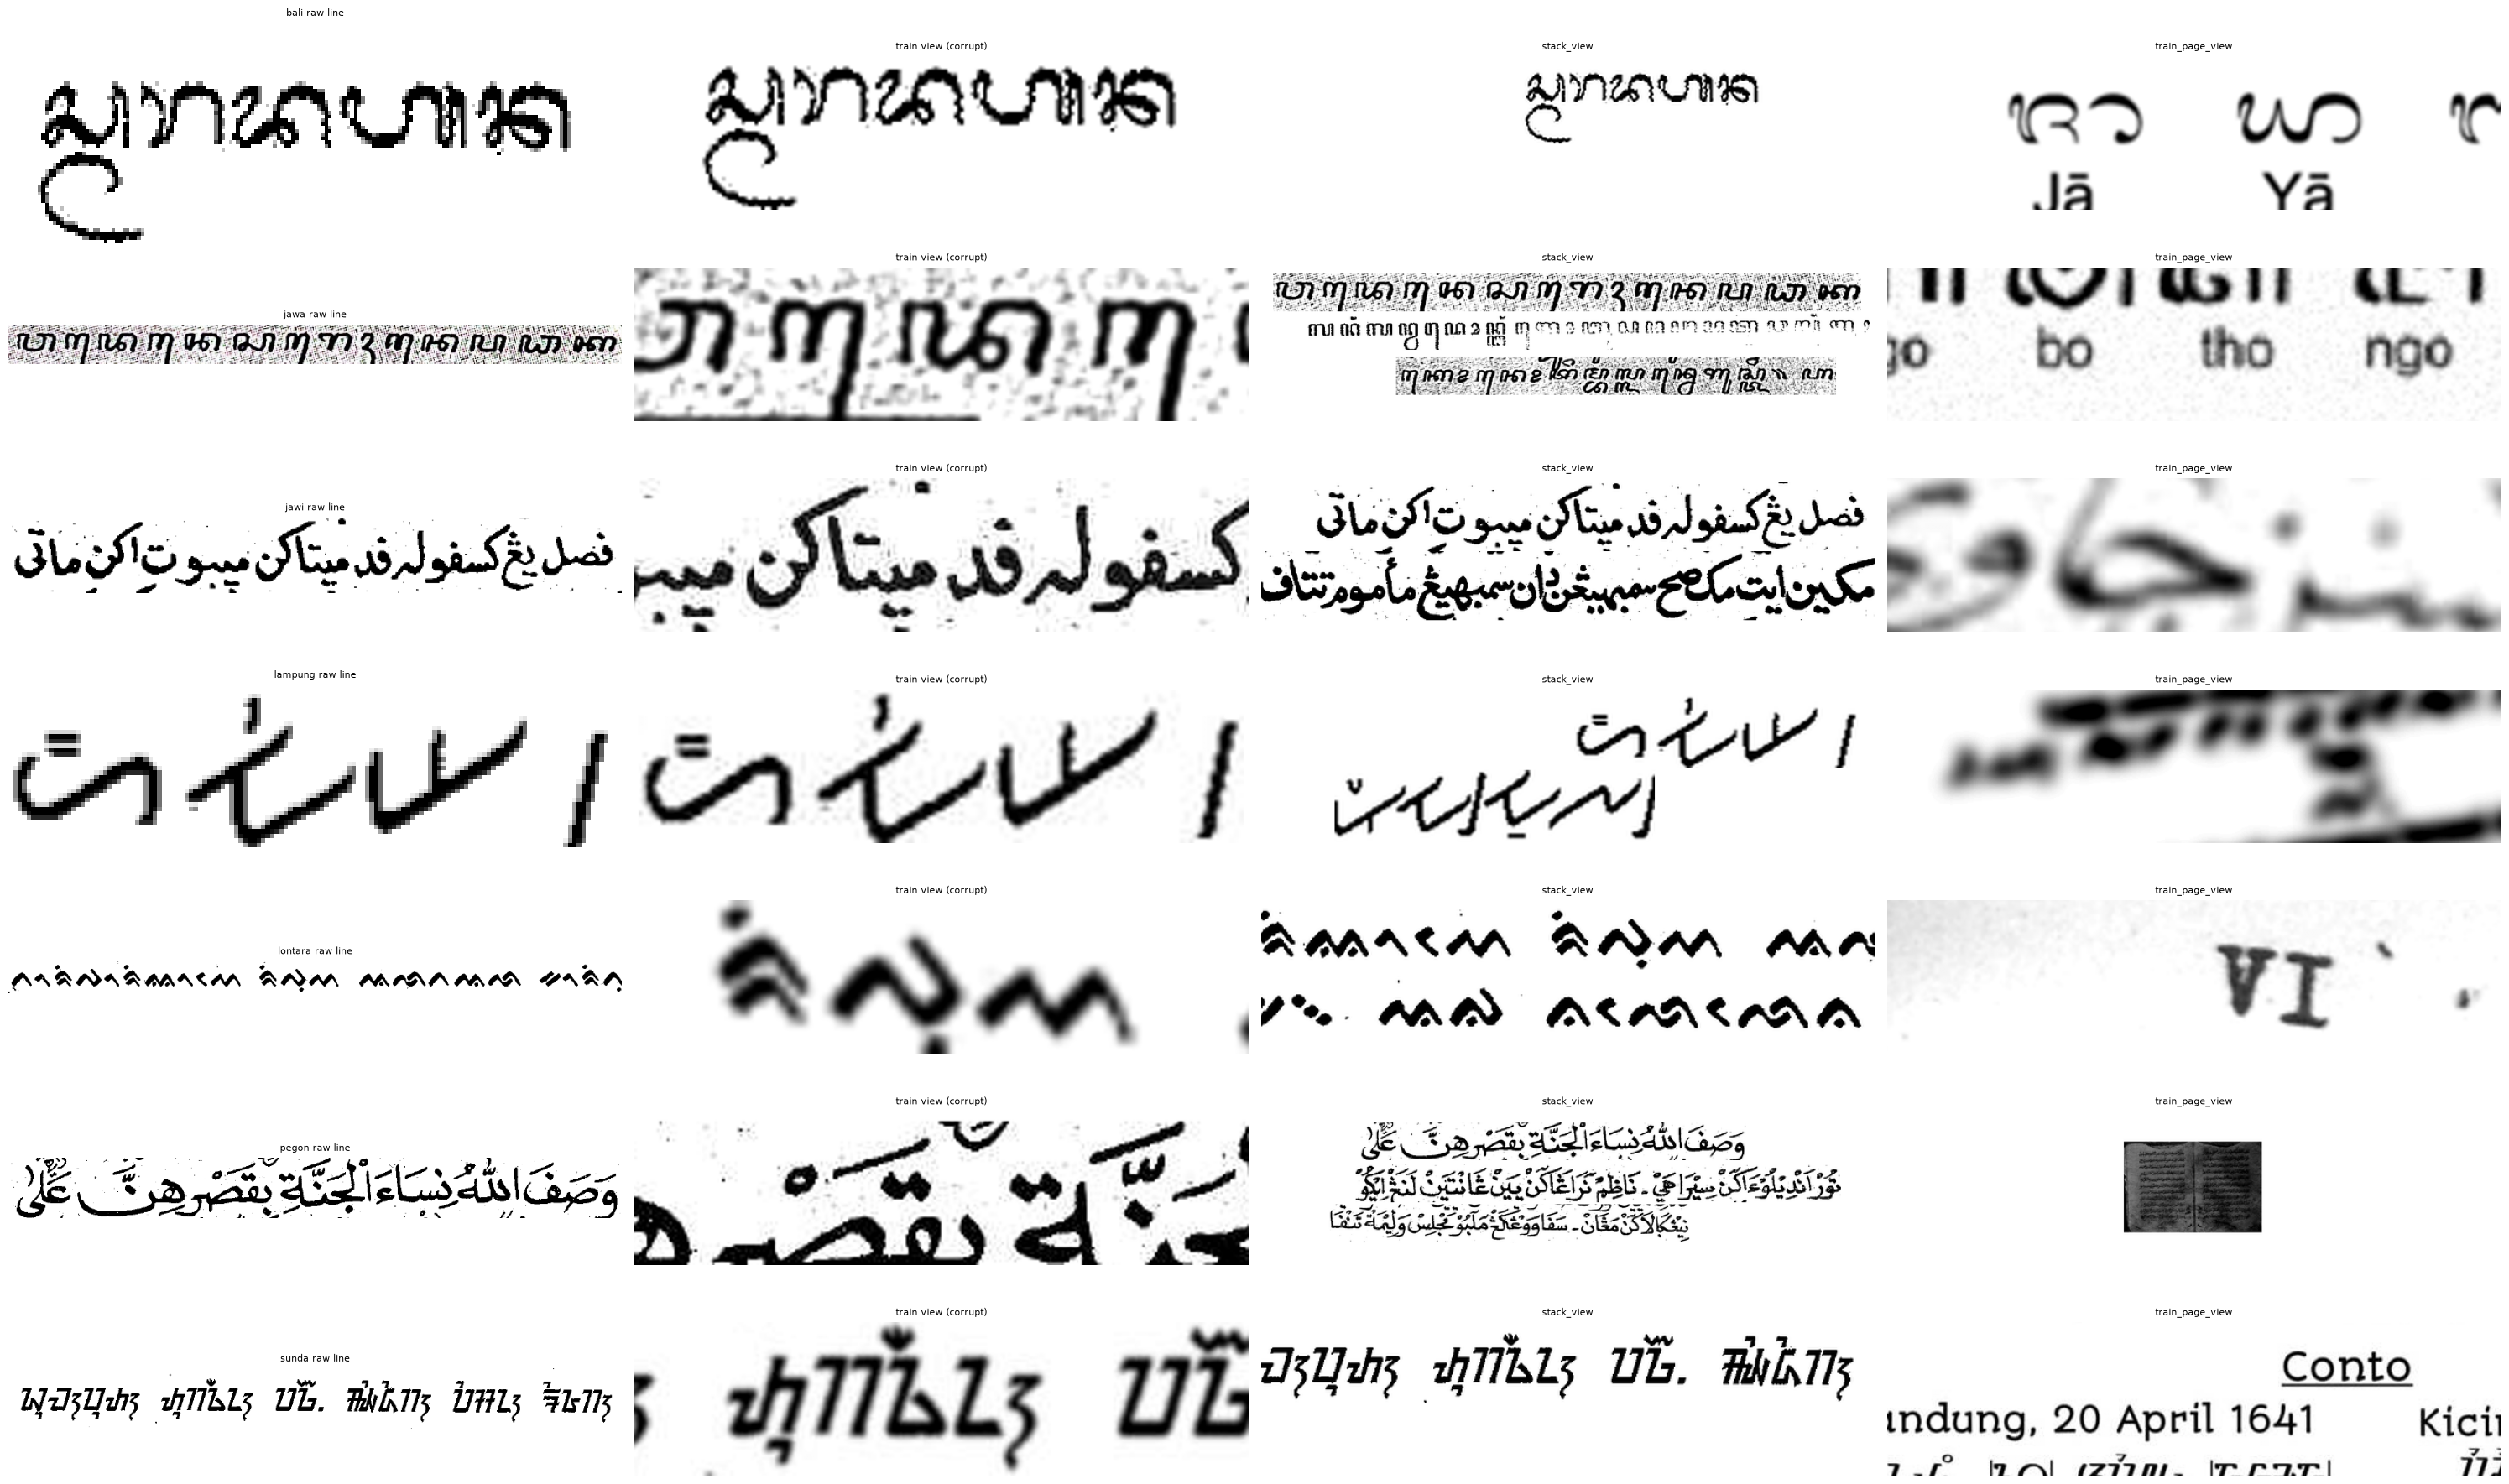

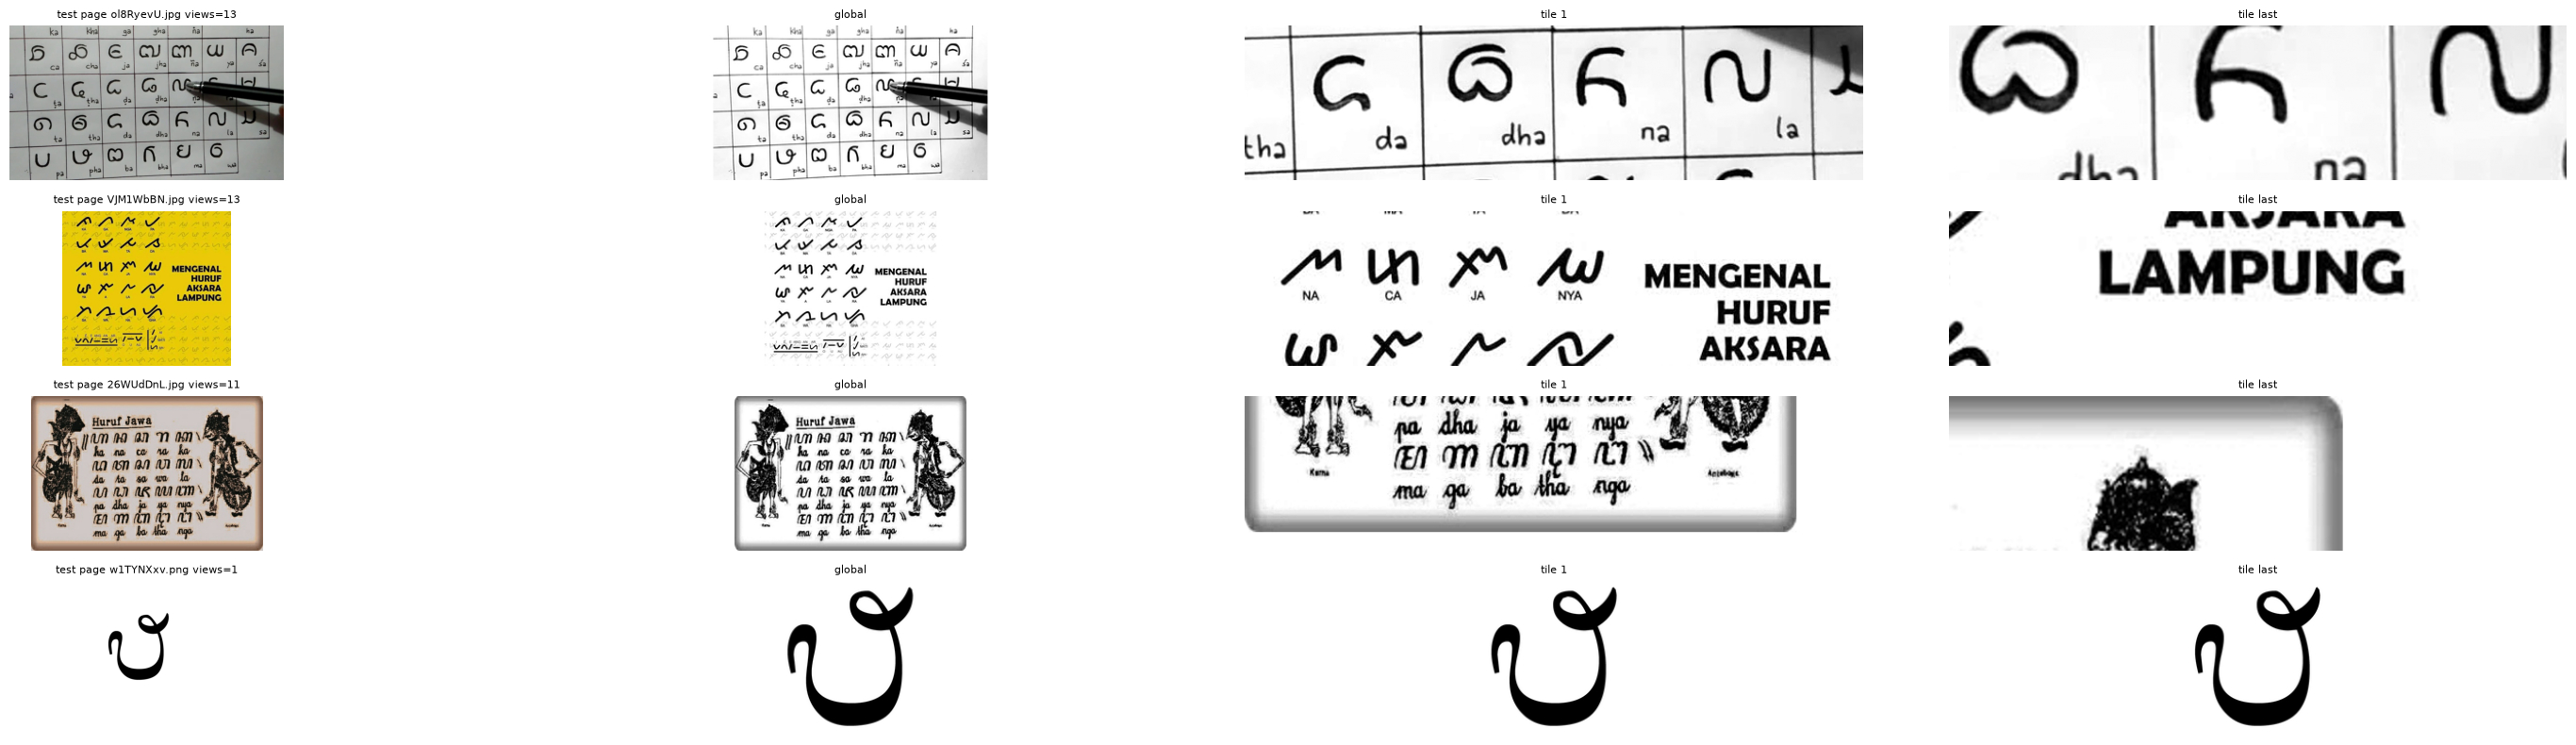

       count  median  blank  >50% black
kind                                   
page      40   0.083  0.025       0.000
plain    481   0.128  0.000       0.004
stack     79   0.081  0.000       0.000
test         tile ink median=0.147 blank=0.37% >50% black=1.41%
train clean  tile ink median=0.142 blank=0.09% >50% black=0.20%


In [5]:
MEAN_G = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(1, 3, 1, 1)
STD_G = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(1, 3, 1, 1)


def gpu_norm(x):
    return (x.float().div_(255).expand(-1, 3, -1, -1) - MEAN_G) / STD_G


class TrainDS(Dataset):
    # page -> (corrupt p=.5) preprocess -> train_page_view ; line -> p=STACK_P stack_view of same-class fold lines ;
    # otherwise v2 path corrupt -> preprocess -> random window. Seed = (SEED, epoch, image).
    def __init__(self, idx):
        self.idx, self.epoch = np.asarray(idx), 0
        lines = [j for j in self.idx if train.ctype[j] == 'line']
        self.pool = {c: [j for j in lines if y_all[j] == c] for c in range(len(LABELS))}

    def __len__(self):
        return len(self.idx)

    def view(self, j, rng, force=None):
        kind = force or ('page' if is_page[j] else ('stack' if train.ctype[j] == 'line' and rng.random() < STACK_P else 'plain'))
        if kind == 'page':
            img = Image.fromarray(train_raw[j])
            if rng.random() < PAGE_CORRUPT_P:
                img = corrupt(img, rng)
            return train_page_view(preprocess(img), rng, H, W), kind
        if kind == 'stack':
            others = rng.sample(self.pool[y_all[j]], min(3, len(self.pool[y_all[j]])))
            return stack_view([Image.fromarray(train_pp[k]) for k in [j] + others], rng, H, W), kind
        return to_canvas(preprocess(corrupt(Image.fromarray(train_raw[j]), rng)), H, W, train=True, rng=rng)[0], kind

    def __getitem__(self, i):
        j = int(self.idx[i])
        rng = random.Random(f'{SEED}-{self.epoch}-{j}')
        v, _ = self.view(j, rng)
        return torch.from_numpy(np.asarray(v, dtype=np.uint8).copy()).unsqueeze(0), int(y_all[j])


def subset_tiles(tiles, owner, idx):
    pos = {int(j): k for k, j in enumerate(idx)}
    m = np.isin(owner, idx)
    return tiles[m], np.array([pos[int(o)] for o in owner[m]])


@torch.inference_mode()
def predict_logprob(model, tiles, owner, page_mask):
    # per image log-probs. non-page: log_softmax(mean tile logits) (v2). page: conf-weighted mean log-prob (prepro/07 e4)
    model.eval()
    n = len(page_mask)
    logits = []
    for s in range(0, len(tiles), EVAL_BATCH):
        x = gpu_norm(torch.from_numpy(tiles[s:s + EVAL_BATCH]).to(DEVICE).unsqueeze(1))
        with torch.autocast('cuda', dtype=torch.bfloat16):
            logits.append(model(x).float().cpu())
    lg = torch.cat(logits).double(); o = torch.from_numpy(owner).long()
    cnt = torch.zeros(n, 1, dtype=torch.float64).index_add_(0, o, torch.ones(len(o), 1, dtype=torch.float64))
    assert (cnt > 0).all()
    mean_lg = torch.zeros(n, lg.shape[1], dtype=torch.float64).index_add_(0, o, lg) / cnt
    out = torch.log_softmax(mean_lg, 1)
    lp = torch.log_softmax(lg, 1); w = lp.exp().max(1).values.pow(2).unsqueeze(1)
    page_lp = torch.zeros_like(mean_lg).index_add_(0, o, lp * w) / torch.zeros(n, 1, dtype=torch.float64).index_add_(0, o, w).clamp_min(1e-9)
    pm = torch.from_numpy(np.asarray(page_mask))
    out[pm] = torch.log_softmax(page_lp[pm], 1)
    return out.numpy()


ds_vis = TrainDS(np.arange(len(train)))
fig, axes = plt.subplots(len(LABELS), 4, figsize=(30, 2.6 * len(LABELS)))
for r, lab in enumerate(LABELS):
    rng = random.Random(r)
    j_line = int(train.index[(train.label == lab) & (train.ctype == 'line')].to_series().sample(1, random_state=r).iloc[0])
    pages_lab = train.index[(train.label == lab) & (train.ctype == 'page')]
    j_page = int(pages_lab.to_series().sample(1, random_state=r).iloc[0]) if len(pages_lab) else j_line
    axes[r, 0].imshow(train_raw[j_line]); axes[r, 0].set_title(f'{lab} raw line', fontsize=8)
    axes[r, 1].imshow(ds_vis.view(j_line, rng, 'plain')[0], cmap='gray', vmin=0, vmax=255); axes[r, 1].set_title('train view (corrupt)', fontsize=8)
    axes[r, 2].imshow(ds_vis.view(j_line, rng, 'stack')[0], cmap='gray', vmin=0, vmax=255); axes[r, 2].set_title('stack_view', fontsize=8)
    axes[r, 3].imshow(ds_vis.view(j_page, rng, 'page' if is_page[j_page] else 'plain')[0], cmap='gray', vmin=0, vmax=255); axes[r, 3].set_title('train_page_view', fontsize=8)
    for a in axes[r]: a.axis('off')
plt.tight_layout(); plt.savefig(OUT / 'samples_train.png', dpi=55); plt.show(); plt.close(fig)

tp = test.index[test.ctype == 'page'].to_series().sample(4, random_state=0)
fig, axes = plt.subplots(4, 4, figsize=(30, 8))
for r, j in enumerate(tp):
    v = test_tiles[test_owner == j]
    axes[r, 0].imshow(Image.open(test.path[j]).convert('RGB')); axes[r, 0].set_title(f'test page {test.image_id[j]} views={len(v)}', fontsize=8)
    for c, t in enumerate([0, 1, len(v) - 1]):
        axes[r, c + 1].imshow(v[min(t, len(v) - 1)], cmap='gray', vmin=0, vmax=255); axes[r, c + 1].set_title(['global', 'tile 1', 'tile last'][c], fontsize=8)
    for a in axes[r]: a.axis('off')
plt.tight_layout(); plt.savefig(OUT / 'samples_test_pages.png', dpi=55); plt.show(); plt.close(fig)

# degenerate inputs: sample up to 600 train views
stats = []
for i, j in enumerate(np.random.default_rng(0).choice(len(train), min(600, len(train)), replace=False)):
    v, kind = ds_vis.view(int(j), random.Random(i))
    f = (np.asarray(v) < 128).mean(); stats.append((kind, f))
st = pd.DataFrame(stats, columns=['kind', 'ink'])
print(st.groupby('kind').ink.agg(['count', 'median', lambda s: (s < .005).mean(), lambda s: (s > .5).mean()]).rename(columns={'<lambda_0>': 'blank', '<lambda_1>': '>50% black'}).round(3))
for name, t in [('test', test_tiles), ('train clean', clean_tiles)]:
    f = (t < 128).mean(axis=(1, 2)); print(f'{name:12s} tile ink median={np.median(f):.3f} blank={np.mean(f < .005):.2%} >50% black={np.mean(f > .5):.2%}')

## Model, optimizer, training per fold

In [6]:
def make_model():
    m = timm.create_model(MODEL_NAME, pretrained=True, num_classes=len(LABELS), img_size=(H, W), global_pool='token')
    if GRAD_CKPT:
        m.set_grad_checkpointing(True)
    return m.to(DEVICE)


def make_optimizer(model):
    head_ids = {id(p) for p in model.get_classifier().parameters()}
    groups = param_groups_layer_decay(model, weight_decay=WEIGHT_DECAY, layer_decay=LAYER_DECAY, no_weight_decay_list=model.no_weight_decay())
    for g in groups:
        g['params'] = [p for p in g['params'] if id(p) not in head_ids]
    groups = [g for g in groups if g['params']]
    groups.append({'params': list(model.get_classifier().parameters()), 'weight_decay': WEIGHT_DECAY, 'lr_scale': HEAD_LR / BASE_LR})
    for g in groups:
        g['base_lr'] = BASE_LR * g.get('lr_scale', 1.0); g['lr'] = g['base_lr']
    assert sum(p.numel() for g in groups for p in g['params']) == sum(p.numel() for p in model.parameters())
    return torch.optim.AdamW(groups, lr=BASE_LR, fused=True)


def mf1(y, lp, w=None):
    return f1_score(y, lp.argmax(1), labels=list(range(len(LABELS))), average='macro', zero_division=0, sample_weight=w)


def run_fold(k):
    done = OUT / f'fold{k}_test_logprob.npy'
    if done.exists():
        print(f'fold {k}: sudah selesai, skip'); return
    tr_idx, va_idx = np.where(train.fold != k)[0], np.where(train.fold == k)[0]
    seed_all(SEED + k)
    model, t_start = make_model(), time.time()
    opt = make_optimizer(model)
    counts = np.bincount(y_all[tr_idx], minlength=len(LABELS))
    cw = 1 / np.sqrt(counts); cw = cw / cw.mean()
    crit = nn.CrossEntropyLoss(weight=torch.tensor(cw, dtype=torch.float32, device=DEVICE), label_smoothing=LABEL_SMOOTHING)
    boost = np.where(is_page[tr_idx], PAGE_BOOST, np.where(nonline[tr_idx], NONLINE_BOOST, 1.0))
    samp_w = torch.tensor(train.weight.values[tr_idx] * boost, dtype=torch.double)
    steps_per_epoch = (len(tr_idx) // MICRO_BATCH) // ACCUM
    total, warm = EPOCHS * steps_per_epoch, WARMUP_EPOCHS * steps_per_epoch
    def lr_factor(step):
        if step < warm:
            return (step + 1) / warm
        return 0.01 + 0.99 * 0.5 * (1 + math.cos(math.pi * min(1.0, (step - warm) / max(1, total - warm))))

    vc = subset_tiles(clean_tiles, clean_owner, va_idx)
    vt = subset_tiles(tl_tiles, tl_owner, va_idx)
    y_va, pm_va, w_va = y_all[va_idx], is_page[va_idx], val_w_all[va_idx]
    ds = TrainDS(tr_idx)
    best, stale, step, hist = -1.0, 0, 0, []
    torch.cuda.reset_peak_memory_stats()
    for epoch in range(EPOCHS):
        ds.epoch = epoch
        sampler = WeightedRandomSampler(samp_w, num_samples=len(tr_idx), replacement=True,
                                        generator=torch.Generator().manual_seed(SEED * 1000 + k * 100 + epoch))
        loader = DataLoader(ds, batch_size=MICRO_BATCH, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True, prefetch_factor=4)
        model.train(); opt.zero_grad(set_to_none=True)
        t0, loss_sum, seen = time.time(), 0.0, 0
        for it, (x, y) in enumerate(loader, 1):
            x, y = gpu_norm(x.to(DEVICE, non_blocking=True)), y.to(DEVICE, non_blocking=True)
            with torch.autocast('cuda', dtype=torch.bfloat16):
                logits = model(x)
            loss = crit(logits.float(), y)
            assert torch.isfinite(loss), f'loss non-finite fold {k} epoch {epoch} iter {it}'
            (loss / ACCUM).backward()
            if it % ACCUM == 0:
                for g in opt.param_groups:
                    g['lr'] = g['base_lr'] * lr_factor(step)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step(); opt.zero_grad(set_to_none=True); step += 1
            loss_sum += loss.item() * len(y); seen += len(y)
        train_s = time.time() - t0
        lc = predict_logprob(model, *vc, pm_va)
        lt = predict_logprob(model, *vt, pm_va)
        rec = dict(fold=k, epoch=epoch + 1, loss=loss_sum / seen, f1_clean=mf1(y_va, lc), f1_testlike=mf1(y_va, lt),
                   f1_testlike_reweighted=mf1(y_va, lt, w_va), page_acc=float((lt.argmax(1)[pm_va] == y_va[pm_va]).mean()),
                   line_acc=float((lt.argmax(1)[train.ctype.values[va_idx] == 'line'] == y_va[train.ctype.values[va_idx] == 'line']).mean()),
                   train_s=round(train_s), imgs_per_s=round(seen / train_s))
        hist.append(rec); print(json.dumps(rec), flush=True)
        if rec['f1_testlike_reweighted'] > best:  # select on the LB proxy (test type mix), eda/08
            best, stale = rec['f1_testlike_reweighted'], 0
            best_state = {n: v.detach().to('cpu', copy=True) for n, v in model.state_dict().items()}
            best_lp = (lc, lt)
        else:
            stale += 1
            if stale >= PATIENCE:
                print(f'early stop fold {k} epoch {epoch + 1}'); break
    model.load_state_dict(best_state)
    np.save(OUT / f'fold{k}_val_idx.npy', va_idx)
    np.save(OUT / f'fold{k}_oof_clean_logprob.npy', best_lp[0])
    np.save(OUT / f'fold{k}_oof_testlike_logprob.npy', best_lp[1])
    pd.DataFrame(hist).to_csv(OUT / f'fold{k}_history.csv', index=False)
    if SAVE_WEIGHTS:
        torch.save({n: v.to(torch.bfloat16) if v.is_floating_point() else v for n, v in best_state.items()}, OUT / f'fold{k}_best_bf16.pt')
    np.save(done, predict_logprob(model, test_tiles, test_owner, (test.ctype == 'page').values))
    print(f'fold {k}: best reweighted={best:.4f} | {(time.time() - t_start) / 60:.1f} min | peak VRAM {torch.cuda.max_memory_allocated() / 2**30:.1f} GB')
    del model, opt, best_state
    gc.collect(); torch.cuda.empty_cache()

In [ ]:
for k in FOLDS:
    run_fold(k)

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.21GB            

model.safetensors: downloading bytes:           |  0.00B            

## OOF evaluation per content type + LB proxy

In [ ]:
done_folds = [k for k in FOLDS if (OUT / f'fold{k}_test_logprob.npy').exists()]
assert done_folds, 'belum ada fold selesai'
idx = np.concatenate([np.load(OUT / f'fold{k}_val_idx.npy') for k in done_folds])
oof_c = np.concatenate([np.load(OUT / f'fold{k}_oof_clean_logprob.npy') for k in done_folds])
oof_t = np.concatenate([np.load(OUT / f'fold{k}_oof_testlike_logprob.npy') for k in done_folds])
y_oof, ct_oof, w_oof = y_all[idx], train.ctype.values[idx], val_w_all[idx]

fold_df = pd.DataFrame([pd.read_csv(OUT / f'fold{k}_history.csv').sort_values('f1_testlike_reweighted').iloc[-1] for k in done_folds])
display(fold_df.round(4)); fold_df.to_csv(OUT / 'fold_metrics.csv', index=False)

rows = []
for t in CTYPES:
    m = ct_oof == t
    rows.append(dict(ctype=t, n=int(m.sum()), acc_clean=(oof_c.argmax(1)[m] == y_oof[m]).mean(), acc_testlike=(oof_t.argmax(1)[m] == y_oof[m]).mean(),
                     v2_acc_corrupt={'line': .992, 'block': .973, 'glyph': .979, 'page': .744}[t]))
per_type = pd.DataFrame(rows).round(4); display(per_type); per_type.to_csv(OUT / 'oof_per_ctype.csv', index=False)

summary = dict(run=RUN_NAME, folds=done_folds, oof_f1_clean=mf1(y_oof, oof_c), oof_f1_testlike=mf1(y_oof, oof_t),
               oof_f1_testlike_reweighted_LB_proxy=mf1(y_oof, oof_t, w_oof),
               v2_reference=dict(oof_f1_corrupt=0.9735, reweighted=0.9299, public_lb=0.91514))
print(json.dumps(summary, indent=2, default=float))

rep = classification_report(y_oof, oof_t.argmax(1), target_names=LABELS, output_dict=True, zero_division=0)
display(pd.DataFrame(rep).T.round(4)); pd.DataFrame(rep).T.to_csv(OUT / 'oof_testlike_per_class.csv')
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
for a, lp, t in [(ax[0], oof_t, 'OOF test-like (all)'), (ax[1], oof_t[ct_oof == 'page'], 'OOF test-like (page)')]:
    yy = y_oof if t.endswith('(all)') else y_oof[ct_oof == 'page']
    ConfusionMatrixDisplay(confusion_matrix(yy, lp.argmax(1), labels=range(7)), display_labels=LABELS).plot(ax=a, xticks_rotation=45, colorbar=False); a.set_title(t)
plt.tight_layout(); plt.savefig(OUT / 'oof_confusion.png', dpi=90); plt.show(); plt.close(fig)
pd.DataFrame({'image_id': train.image_id.values[idx], 'label': train.label.values[idx], 'fold': train.fold.values[idx], 'ctype': ct_oof,
              'pred_clean': np.array(LABELS)[oof_c.argmax(1)], 'pred_testlike': np.array(LABELS)[oof_t.argmax(1)]}).to_csv(OUT / 'oof_predictions.csv', index=False)

## Submission
`submission.csv` = rata-rata probabilitas fold (utama). `submission_prior.csv` = + koreksi prior EM (eda/11: test pegon↑ jawi↓) — **eksperimen**, submit terpisah untuk mengukur.

In [ ]:
probs = np.mean([np.exp(np.load(OUT / f'fold{k}_test_logprob.npy')) for k in done_folds], axis=0)
probs /= probs.sum(1, keepdims=True)
assert probs.shape == (len(test), len(LABELS))

src_prior = np.exp(oof_t).mean(0); pri = src_prior.copy()
for _ in range(100):
    adj = probs * (pri / src_prior); adj /= adj.sum(1, keepdims=True)
    new = adj.mean(0)
    if np.abs(new - pri).max() < 1e-6:
        break
    pri = new


def write(p, name):
    pred = np.array(LABELS, dtype=object)[p.argmax(1)]
    if USE_TWINS and len(twins):
        tw = test.image_id.map(twins.set_index('image_id').train_label); m = tw.notna().values
        pred[m] = tw[m].values
    sub = sample_sub[['image_id']].merge(pd.DataFrame({'image_id': test.image_id, 'label': pred}), on='image_id', how='left')
    assert len(sub) == len(sample_sub) and sub.label.notna().all() and set(sub.label) <= set(LABELS)
    sub.to_csv(OUT / name, index=False)
    return sub


sub = write(probs, 'submission.csv')
sub_prior = write(adj, 'submission_prior.csv')
pd.DataFrame(probs, columns=LABELS).assign(image_id=test.image_id.values, ctype=test.ctype.values).to_csv(OUT / 'test_probabilities.csv', index=False)
print(f'prior correction changes {(sub.label != sub_prior.label).sum()} rows')
display(pd.DataFrame({'pred_%': sub.label.value_counts(normalize=True) * 100, 'prior_%': sub_prior.label.value_counts(normalize=True) * 100,
                      'EM_prior_%': pd.Series(pri * 100, index=LABELS), 'train_%': train.label.value_counts(normalize=True) * 100}).round(1))
display((pd.crosstab(test.ctype, sub.set_index('image_id').label.reindex(test.image_id).values, normalize='index') * 100).round(1))
v2_sub = ROOT / 'results/v2/main/submission.csv'
if v2_sub.exists():
    s2 = sample_sub[['image_id']].merge(pd.read_csv(v2_sub), on='image_id')
    diff = s2.label.values != sub.label.values
    print(f'beda dengan v2: {diff.mean():.1%}; per ctype:', test.set_index('image_id').ctype.reindex(sub.image_id)[diff].value_counts().to_dict())

config = {k: v for k, v in dict(globals()).items() if k.isupper() and isinstance(v, (int, float, str, bool, list, tuple, dict))}
config.update(torch=torch.__version__, timm=timm.__version__, python=platform.python_version(), gpu=torch.cuda.get_device_name())
(OUT / 'config.json').write_text(json.dumps(config, indent=2, default=str))
(OUT / 'summary.json').write_text(json.dumps(summary, indent=2, default=float))
print('SELESAI ->', OUT / 'submission.csv')